# **FEATURE REDUCTION EXPERIMENT**

Setelah melakukan analisis *feature importance* pada model Random Forest dan XGBoost,
ditemukan bahwa terdapat **gap signifikan** antara 10 fitur teratas dengan fitur-fitur
di bawahnya. Bahkan, beberapa fitur (`soil_type`, `fertilizer_usage`, `growth_stage`,
`water_source_type`) memiliki nilai *gain* nol pada XGBoost — artinya tidak berkontribusi
sama sekali terhadap prediksi.

Eksperimen ini bertujuan untuk:
1. Memvalidasi apakah **10 fitur dominan** cukup untuk mempertahankan performa model
2. Mengukur **trade-off** antara kompleksitas fitur dan akurasi
3. Menyederhanakan pipeline inferensi untuk kebutuhan deployment

**Hipotesis:** Model dengan 10 fitur inti akan mempertahankan akurasi dengan selisih < 2%
dibanding model dengan fitur lengkap.

## **Import Library**

In [29]:
import os
import joblib

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from xgboost import XGBClassifier
import warnings
warnings.filterwarnings("ignore")

## **Load Data, Model, & Label Encoder**

Data dan model yang digunakan merupakan hasil dari pipeline sebelumnya:
- `train_data.csv` / `test_data.csv` — data yang telah diproses
- `random_forest_best.pkl` / `xgboost_best.pkl` — model terbaik hasil hyperparameter tuning
- `label_encoder.pkl` — encoder untuk nama kelas tanaman

In [30]:
# Load data
train_data = pd.read_csv('../../data/processed/train_data.csv')
test_data  = pd.read_csv('../../data/processed/test_data.csv')

X_train = train_data.drop('label_encoded', axis=1)
y_train = train_data['label_encoded']

X_test = test_data.drop('label_encoded', axis=1)
y_test = test_data['label_encoded']

# Load model dan encoder
label_encoder = joblib.load('../../models/label_encoder.pkl')
best_rf       = joblib.load('../../models/random_forest_best.pkl')
best_xgb      = joblib.load('../../models/xgboost_best.pkl')
label_names   = label_encoder.classes_

print(f"Train shape    : {X_train.shape}")
print(f"Test shape     : {X_test.shape}")
print(f"Total kelas    : {len(label_names)} tanaman")
print(f"Total fitur    : {X_train.shape[1]}")

Train shape    : (1760, 26)
Test shape     : (440, 26)
Total kelas    : 22 tanaman
Total fitur    : 26


## **Definisi Core Features**

Pemilihan 10 fitur inti didasarkan pada konsensus antara dua model:
- **Random Forest** menggunakan metrik *Mean Decrease in Impurity* (MDI)
- **XGBoost** menggunakan metrik *Average Gain*

Fitur-fitur ini didominasi oleh **nutrien tanah** (N, P, K dan rasionya) serta
**variabel iklim** (rainfall, humidity, temperature) — secara agronomis, ini konsisten
dengan faktor utama yang menentukan kesesuaian tanaman terhadap lahan.

In [31]:
CORE_FEATURES = [
    'K', 'N_K_ratio', 'temp_humidity_idx', 'rainfall',
    'N_P_ratio', 'P', 'humidity', 'P_K_ratio', 'N', 'temperature'
]

DROPPED_FEATURES = [f for f in X_train.columns if f not in CORE_FEATURES]

print(f"Fitur dipertahankan ({len(CORE_FEATURES)})  : {CORE_FEATURES}")
print(f"\nFitur dihapus ({len(DROPPED_FEATURES)})       : {DROPPED_FEATURES}")
print(f"\nReduksi dimensi : {X_train.shape[1]} → {len(CORE_FEATURES)} fitur "
      f"({len(DROPPED_FEATURES)} fitur dieliminasi, "
      f"{len(DROPPED_FEATURES)/X_train.shape[1]*100:.1f}% reduksi)")

Fitur dipertahankan (10)  : ['K', 'N_K_ratio', 'temp_humidity_idx', 'rainfall', 'N_P_ratio', 'P', 'humidity', 'P_K_ratio', 'N', 'temperature']

Fitur dihapus (16)       : ['ph', 'soil_moisture', 'soil_type', 'sunlight_exposure', 'wind_speed', 'co2_concentration', 'organic_matter', 'irrigation_frequency', 'crop_density', 'pest_pressure', 'fertilizer_usage', 'growth_stage', 'urban_area_proximity', 'water_source_type', 'frost_risk', 'water_usage_efficiency']

Reduksi dimensi : 26 → 10 fitur (16 fitur dieliminasi, 61.5% reduksi)


In [32]:
X_train_red = X_train[CORE_FEATURES]
X_test_red  = X_test[CORE_FEATURES]

## **Training Model Reduced**

Model dilatih ulang menggunakan **hyperparameter terbaik** yang telah ditemukan pada
tahap tuning sebelumnya (bukan default), sehingga perbandingan yang dilakukan benar-benar
mengisolasi efek pengurangan fitur — bukan perbedaan konfigurasi model.

In [33]:
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# --- Random Forest Reduced ---
rf_params = best_rf.get_params()
rf_reduced = RandomForestClassifier(**rf_params)

print("Training RF Reduced...")
rf_reduced.fit(X_train_red, y_train)
cv_rf_red = cross_val_score(rf_reduced, X_train_red, y_train, cv=stratified_kfold, n_jobs=-1)
print(f"  CV Accuracy : {cv_rf_red.mean():.4f} ± {cv_rf_red.std():.4f}")

# --- XGBoost Reduced ---
xgb_params = best_xgb.get_params()
xgb_reduced = XGBClassifier(**xgb_params)

print("\nTraining XGBoost Reduced...")
xgb_reduced.fit(X_train_red, y_train)
cv_xgb_red = cross_val_score(xgb_reduced, X_train_red, y_train, cv=stratified_kfold, n_jobs=-1)
print(f"  CV Accuracy : {cv_xgb_red.mean():.4f} ± {cv_xgb_red.std():.4f}")

Training RF Reduced...
  CV Accuracy : 0.9886 ± 0.0054

Training XGBoost Reduced...
  CV Accuracy : 0.9920 ± 0.0066


## **Perbandingan Performa: Full vs. Reduced**

Evaluasi dilakukan pada test set untuk membandingkan performa model *full feature*
dengan model *reduced feature* secara objektif.

In [34]:
# Akurasi model full (dari notebook sebelumnya)
acc_rf_full  = accuracy_score(y_test, best_rf.predict(X_test))
acc_xgb_full = accuracy_score(y_test, best_xgb.predict(X_test))

# Akurasi model reduced
acc_rf_red   = accuracy_score(y_test, rf_reduced.predict(X_test_red))
acc_xgb_red  = accuracy_score(y_test, xgb_reduced.predict(X_test_red))

results = pd.DataFrame({
    'Model'        : ['Random Forest', 'XGBoost'],
    'Full Features': [acc_rf_full,  acc_xgb_full],
    'Reduced (10)' : [acc_rf_red,   acc_xgb_red],
    'Drop (%)'     : [
        (acc_rf_full  - acc_rf_red)  * 100,
        (acc_xgb_full - acc_xgb_red) * 100,
    ]
})

print("=" * 60)
print(f"  {'Model':<18} {'Full':>8}   {'Reduced':>8}   {'Drop':>8}")
print("=" * 60)
for _, row in results.iterrows():
    status = "✓ OK" if abs(row['Drop (%)']) < 2 else "⚠ Significant"
    
    print(f"  {row['Model']:<18} {row['Full Features']*100:>7.2f}%  "
          f"{row['Reduced (10)']*100:>7.2f}%  "
          f"{row['Drop (%)']:>7.2f}%  {status}")
print("=" * 60)
print(f"  Fitur digunakan   : {X_train.shape[1]} → {len(CORE_FEATURES)} "
      f"({len(DROPPED_FEATURES)} fitur dieliminasi)")

  Model                  Full    Reduced       Drop
  Random Forest        99.32%    99.32%     0.00%  ✓ OK
  XGBoost              99.55%    99.09%     0.45%  ✓ OK
  Fitur digunakan   : 26 → 10 (16 fitur dieliminasi)


## **Visualisasi Perbandingan**

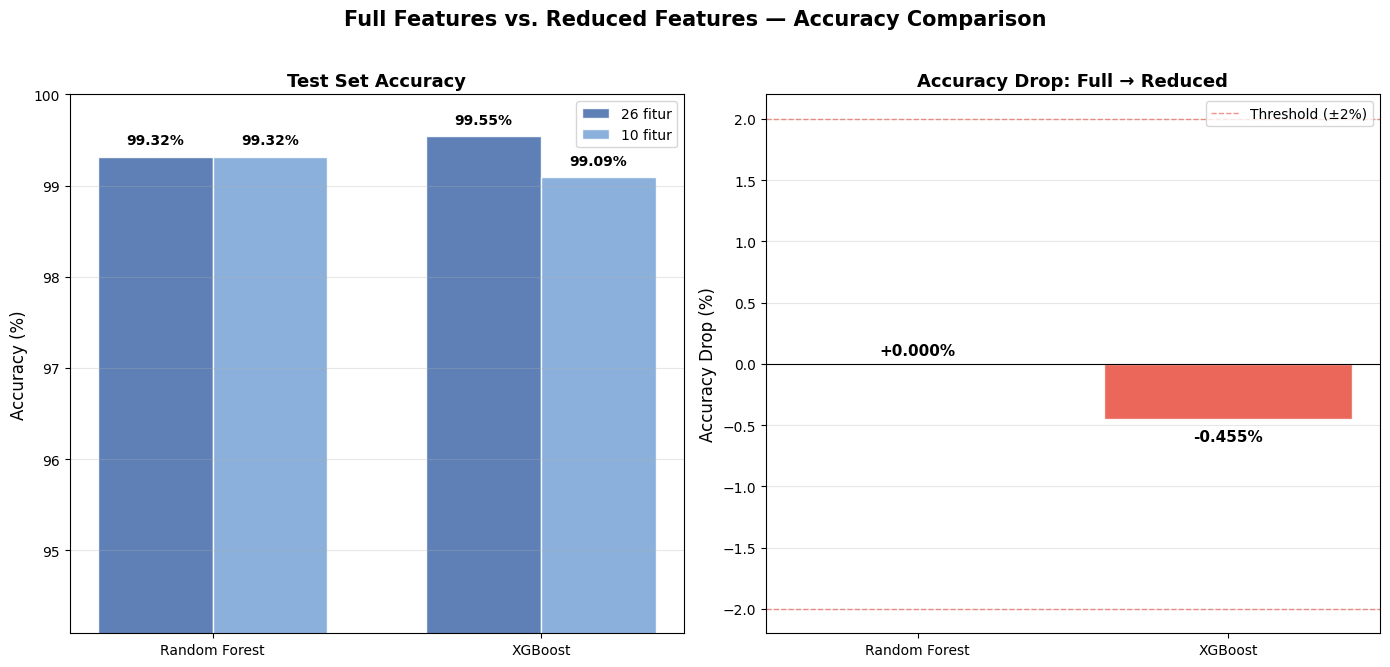

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))
fig.suptitle('Full Features vs. Reduced Features — Accuracy Comparison',
             fontsize=15, fontweight='bold', y=1.02)

model_labels = ['Random Forest', 'XGBoost']
full_accs    = [acc_rf_full * 100,  acc_xgb_full * 100]
red_accs     = [acc_rf_red  * 100,  acc_xgb_red  * 100]
colors_full  = ['#4C72B0']
colors_red   = ['#7FA8D8']

x = np.arange(len(model_labels))
width = 0.35

# Bar chart
ax = axes[0]
bars_full = ax.bar(x - width/2, full_accs, width, label=f'{X_train.shape[1]} fitur',
                   color=colors_full, alpha=0.9, edgecolor='white')
bars_red  = ax.bar(x + width/2, red_accs,  width, label='10 fitur',
                   color=colors_red,  alpha=0.9, edgecolor='white')

for bar in bars_full:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar in bars_red:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Test Set Accuracy', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_labels)
ax.set_ylim(min(full_accs + red_accs) - 5, 100)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Accuracy drop (reduced - full): negative = accuracy turun, positive = naik
ax2 = axes[1]
drops = [acc_rf_red - acc_rf_full, acc_xgb_red - acc_xgb_full]
drop_pct = [d * 100 for d in drops]
bar_colors = ['#2ecc71' if d >= 0 else '#e74c3c' for d in drops]

bars_drop = ax2.bar(model_labels, drop_pct, color=bar_colors, alpha=0.85, edgecolor='white')

for bar, val in zip(bars_drop, drop_pct):
    if val >= 0:
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f'{val:+.3f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
    else:
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() - 0.08,
                 f'{val:+.3f}%', ha='center', va='top', fontsize=11, fontweight='bold')

ax2.axhline(0,    color='black',  linewidth=0.8, linestyle='-')
ax2.axhline(2.0,  color='#e74c3c', linewidth=1,   linestyle='--', alpha=0.6)
ax2.axhline(-2.0, color='#e74c3c', linewidth=1,   linestyle='--', alpha=0.6, label='Threshold (±2%)')

ax2.set_ylabel('Accuracy Drop (%)', fontsize=12)
ax2.set_title('Accuracy Drop: Full → Reduced', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## **Classification Report: Model Reduced**

In [36]:
print("Classification Report — Random Forest (Reduced):")
print(classification_report(
    y_test, rf_reduced.predict(X_test_red), target_names=label_names
))

Classification Report — Random Forest (Reduced):
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.0

In [37]:
print("Classification Report — XGBoost (Reduced):")
print(classification_report(
    y_test, xgb_reduced.predict(X_test_red), target_names=label_names
))

Classification Report — XGBoost (Reduced):
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       0.95      0.95      0.95        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      0.95      0.97        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00     

## **Confusion Matrix: Model Reduced**

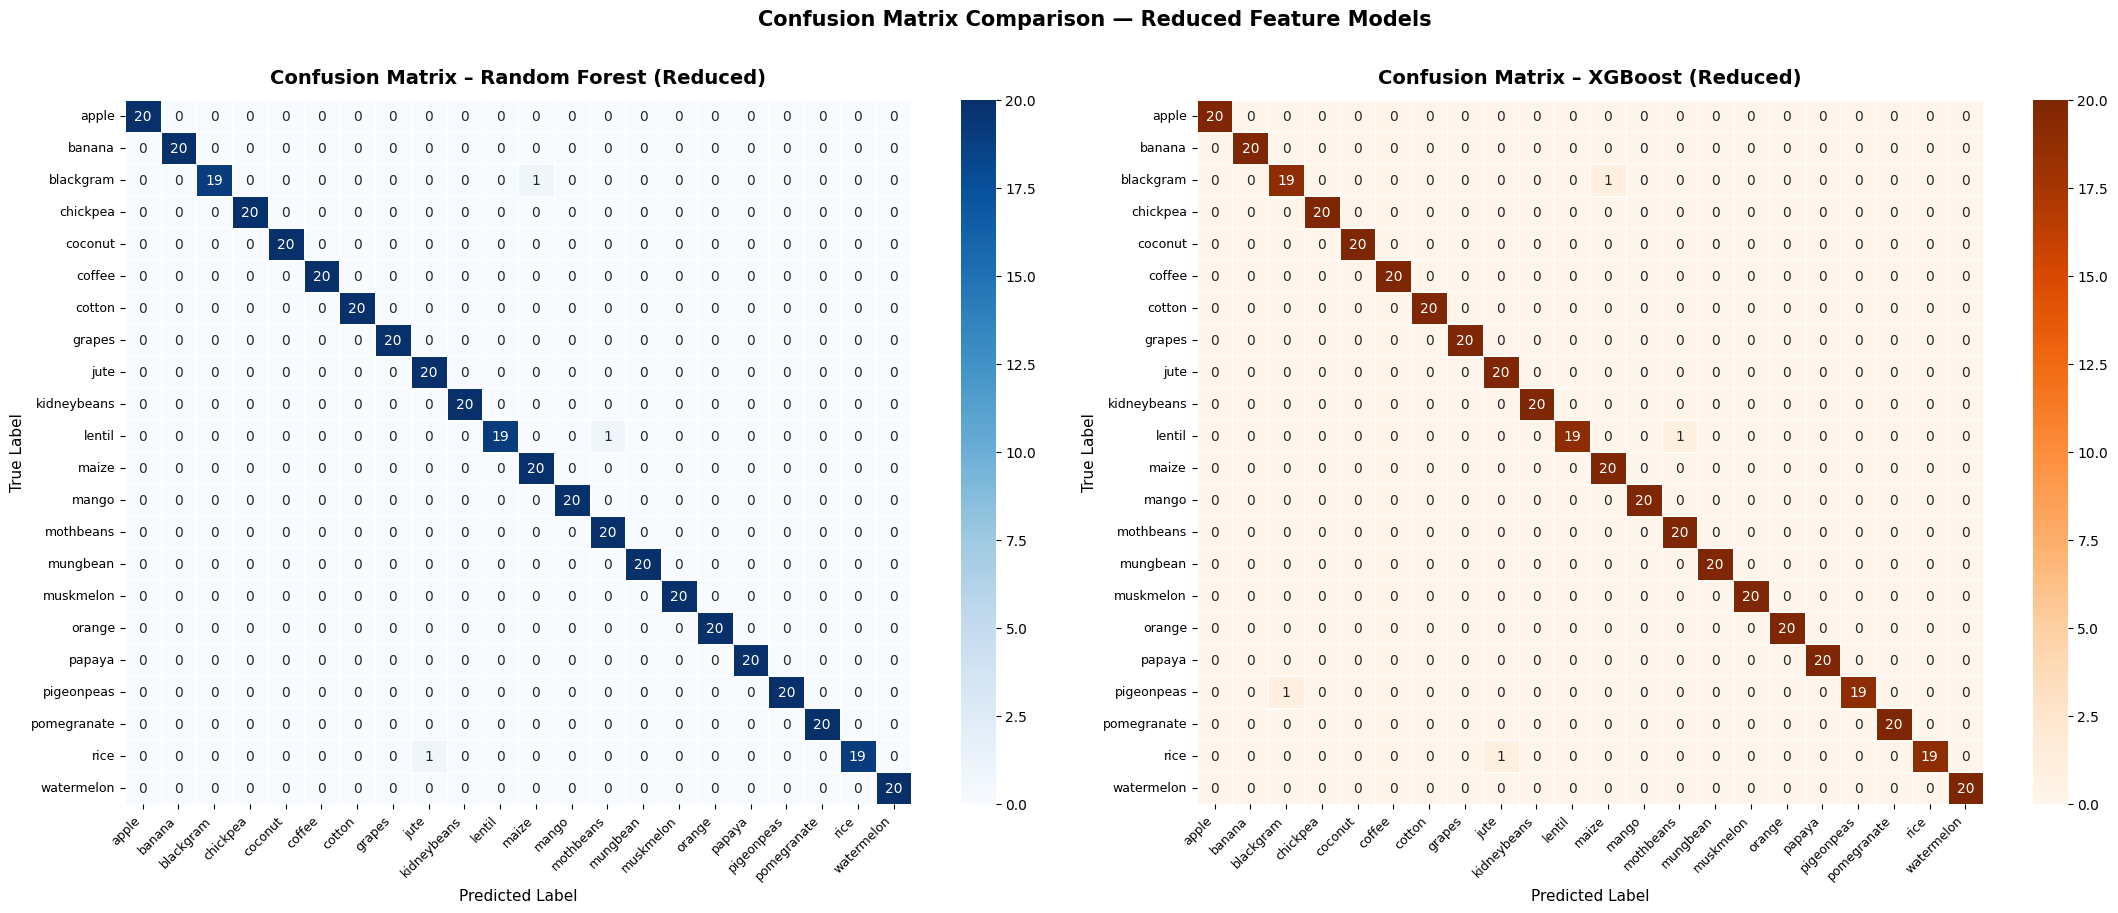

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(22, 9))

for ax, model, y_pred, title, cmap in zip(
    axes,
    [rf_reduced,  xgb_reduced],
    [rf_reduced.predict(X_test_red), xgb_reduced.predict(X_test_red)],
    ['Random Forest (Reduced)', 'XGBoost (Reduced)'],
    ['Blues', 'Oranges']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap,
        xticklabels=label_names, yticklabels=label_names,
        linewidths=0.5, ax=ax
    )
    ax.set_title(f'Confusion Matrix – {title}', fontsize=14, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=9)

plt.suptitle('Confusion Matrix Comparison — Reduced Feature Models',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## **Simpan Model Reduced**

Model dengan fitur terkurangi disimpan sebagai alternatif deployment yang lebih ringan.
File `core_features.pkl` turut disimpan agar pipeline inferensi dapat secara konsisten
menggunakan set fitur yang sama tanpa hardcode.

In [39]:
model_dir = '../../models'
os.makedirs(model_dir, exist_ok=True)

rf_red_path  = os.path.join(model_dir, 'random_forest_reduced.pkl')
xgb_red_path = os.path.join(model_dir, 'xgboost_reduced.pkl')
feat_path    = os.path.join(model_dir, 'core_features.pkl')

joblib.dump(rf_reduced,    rf_red_path)
joblib.dump(xgb_reduced,   xgb_red_path)
joblib.dump(CORE_FEATURES, feat_path)

# Simpan juga XGBoost dalam format native
xgb_json_path = os.path.join(model_dir, 'xgboost_reduced.json')
xgb_reduced.get_booster().save_model(xgb_json_path)

print("Model tersimpan di:")
print(f"  {os.path.abspath(rf_red_path)}")
print(f"  {os.path.abspath(xgb_red_path)}")
print(f"  {os.path.abspath(xgb_json_path)}  (native XGBoost)")
print(f"  {os.path.abspath(feat_path)}  (core feature list)")

Model tersimpan di:
  /Users/anargyaisadhimaheswara/Documents/Semester6/Daming/project-daming/models/random_forest_reduced.pkl
  /Users/anargyaisadhimaheswara/Documents/Semester6/Daming/project-daming/models/xgboost_reduced.pkl
  /Users/anargyaisadhimaheswara/Documents/Semester6/Daming/project-daming/models/xgboost_reduced.json  (native XGBoost)
  /Users/anargyaisadhimaheswara/Documents/Semester6/Daming/project-daming/models/core_features.pkl  (core feature list)


## **Evaluasi Performa Komputasi: Perbandingan Keempat Model**

Mengukur dua dimensi efisiensi komputasi:
- **Waktu Training** — waktu fit model dengan hyperparameter terbaik pada seluruh data train
- **Waktu Inference (1x)** — waktu prediksi satu sampel (rata-rata 500 repetisi)

In [40]:
import time
from sklearn.base import clone

N_REPS = 500  # repetisi untuk inference time yang stabil

def measure_timing(model, X_tr, y_tr, X_te, n_reps=N_REPS):
    m = clone(model)
    t0 = time.perf_counter()
    m.fit(X_tr, y_tr)
    train_t = time.perf_counter() - t0

    sample = X_te.iloc[[0]]
    t0 = time.perf_counter()
    for _ in range(n_reps):
        m.predict(sample)
    infer_t = (time.perf_counter() - t0) / n_reps
    return train_t, infer_t

model_configs = [
    ("Random Forest (Full)",     best_rf,     X_train,     X_test,     y_test),
    ("XGBoost (Full)",           best_xgb,    X_train,     X_test,     y_test),
    ("Random Forest (Reduced)",  rf_reduced,  X_train_red, X_test_red, y_test),
    ("XGBoost (Reduced)",        xgb_reduced, X_train_red, X_test_red, y_test),
]

timing_rows = []
for name, model, X_tr, X_te, y_te in model_configs:
    print(f"Mengukur: {name}...")
    train_t, infer_t = measure_timing(model, X_tr, y_train, X_te)
    acc = accuracy_score(y_te, model.predict(X_te))
    n_fitur = X_tr.shape[1]
    timing_rows.append({
        'Model'                  : name,
        'Jumlah Fitur'           : n_fitur,
        'Test Accuracy (%)'      : round(acc * 100, 2),
        'Training Time (s)'      : round(train_t, 4),
        'Inference Time 1x (ms)' : round(infer_t * 1000, 4),
    })

timing_df = pd.DataFrame(timing_rows)
print("\nSelesai mengukur semua model.\n")

Mengukur: Random Forest (Full)...
Mengukur: XGBoost (Full)...
Mengukur: Random Forest (Reduced)...
Mengukur: XGBoost (Reduced)...

Selesai mengukur semua model.



In [41]:
print("=" * 78)
print(f"  {'Model':<28} {'Fitur':>6}  {'Accuracy':>9}  {'Train (s)':>10}  {'Infer (ms)':>11}")
print("=" * 78)
for _, row in timing_df.iterrows():
    print(f"  {row['Model']:<28} {int(row['Jumlah Fitur']):>6}  "
          f"{row['Test Accuracy (%)']:>8.2f}%  "
          f"{row['Training Time (s)']:>10.4f}  "
          f"{row['Inference Time 1x (ms)']:>10.4f}ms")
print("=" * 78)

# Speedup relatif terhadap RF Full
base_train = timing_df.loc[timing_df['Model'] == 'Random Forest (Full)', 'Training Time (s)'].values[0]
base_infer = timing_df.loc[timing_df['Model'] == 'Random Forest (Full)', 'Inference Time 1x (ms)'].values[0]
print("\nSpeedup relatif terhadap Random Forest (Full):")
for _, row in timing_df.iterrows():
    train_speedup = base_train / row['Training Time (s)']
    infer_speedup = base_infer / row['Inference Time 1x (ms)']
    print(f"  {row['Model']:<28}: train ×{train_speedup:.2f}  |  infer ×{infer_speedup:.2f}")

  Model                         Fitur   Accuracy   Train (s)   Infer (ms)
  Random Forest (Full)             26     99.32%      0.3747     26.0114ms
  XGBoost (Full)                   26     99.55%      1.6889      0.7890ms
  Random Forest (Reduced)          10     99.32%      0.2805     25.8935ms
  XGBoost (Reduced)                10     99.09%      1.6318      0.5793ms

Speedup relatif terhadap Random Forest (Full):
  Random Forest (Full)        : train ×1.00  |  infer ×1.00
  XGBoost (Full)              : train ×0.22  |  infer ×32.97
  Random Forest (Reduced)     : train ×1.34  |  infer ×1.00
  XGBoost (Reduced)           : train ×0.23  |  infer ×44.90


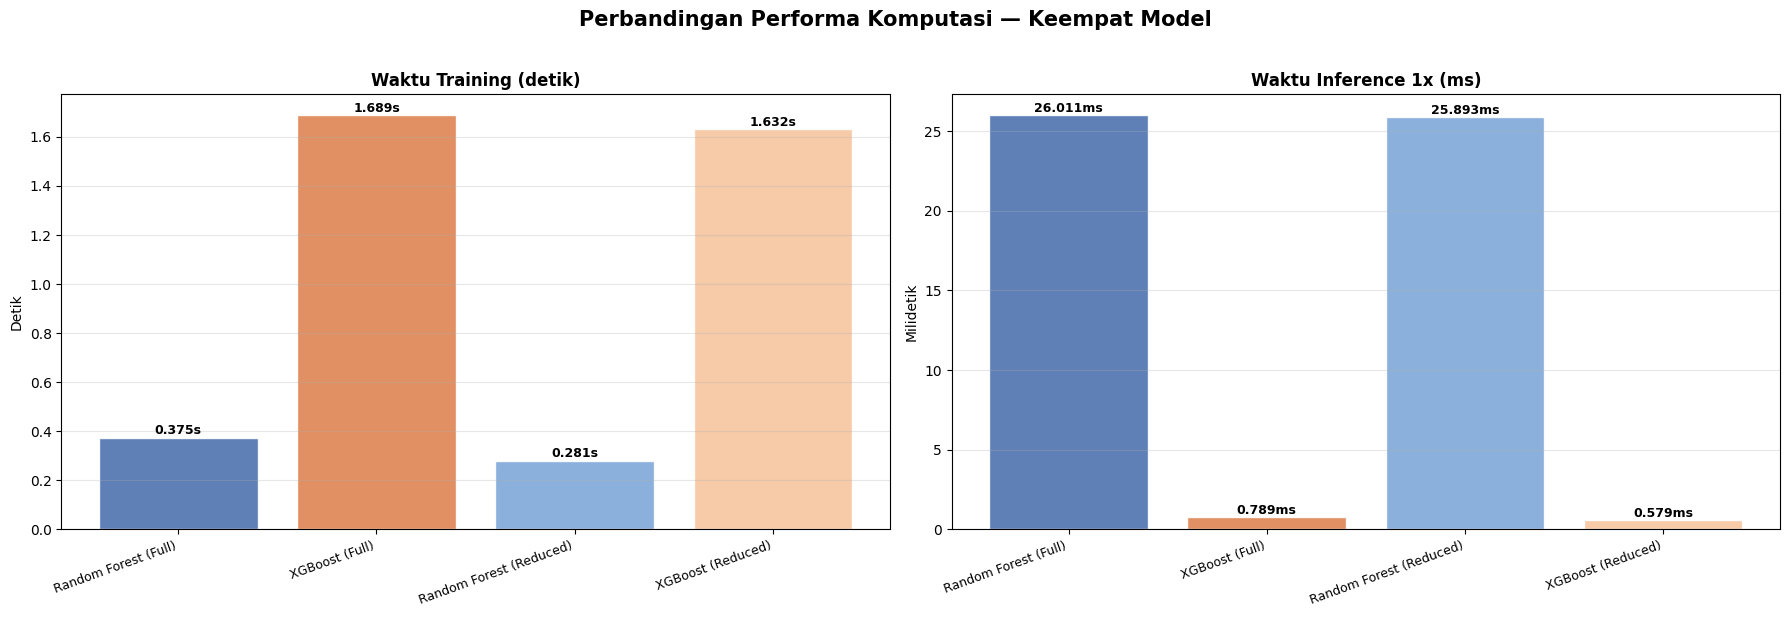

Saved: experiment_compute_comparison.png


In [42]:
model_labels  = timing_df['Model'].tolist()
train_times   = timing_df['Training Time (s)'].tolist()
infer_times   = timing_df['Inference Time 1x (ms)'].tolist()
accuracies    = timing_df['Test Accuracy (%)'].tolist()
palette       = ['#4C72B0', '#DD8452', '#7FA8D8', '#F7C59F']

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Perbandingan Performa Komputasi — Keempat Model', fontsize=15, fontweight='bold', y=1.02)

# Plot 1: Training Time
ax = axes[0]
bars = ax.bar(model_labels, train_times, color=palette, edgecolor='white', alpha=0.9)
for bar, val in zip(bars, train_times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.3f}s', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Waktu Training (detik)', fontsize=12, fontweight='bold')
ax.set_ylabel('Detik')
ax.set_xticklabels(model_labels, rotation=20, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Plot 2: Inference Time
ax = axes[1]
bars = ax.bar(model_labels, infer_times, color=palette, edgecolor='white', alpha=0.9)
for bar, val in zip(bars, infer_times):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f'{val:.3f}ms', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Waktu Inference 1x (ms)', fontsize=12, fontweight='bold')
ax.set_ylabel('Milidetik')
ax.set_xticklabels(model_labels, rotation=20, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../../assets/experiment_compute_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: experiment_compute_comparison.png")